## EDA & Dataförståelse


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import joblib
from pathlib import Path


### Läser in datan och visar de 10 översta raderna

In [2]:
df = pd.read_csv("historical_data.csv")
df.head(10)

,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
0,0,8,ad_post,other,urban,android,38.4,2,1,1,594.16,3,91,0,1,0,2.3,0
1,1,4,ad_post,fashion,urban,android,20.0,1,0,1,134.47,2,150,0,0,0,13.6,0
2,2,4,ad_post,other,metro,ios,46.7,3,1,1,198.52,3,72,0,0,0,4.2,0
3,3,3,ad_post,furniture,metro,android,44.3,3,1,2,141.20,3,0,0,0,0,19.8,0
4,4,1,ad_post,electronics,metro,web,211.2,5,0,0,81.39,3,9,0,0,1,23.3,0
5,5,11,message_send,phones,rural,android,31.9,6,0,2,502.33,5,247,0,0,0,26.3,0
6,6,6,message_send,electronics,rural,android,133.9,9,0,0,46.40,2,188,0,0,0,3.2,0
7,7,3,ad_post,other,metro,android,5.8,3,0,0,209.24,4,0,0,0,1,3.5,0
8,8,14,message_send,fashion,urban,web,38.7,4,0,0,41.47,2,135,0,0,1,14.6,0
9,9,1,message_send,other,rural,android,71.1,1,1,1,432.86,6,88,0,0,1,21.8,0


### Inläsning av datastorleken, datatyper och target-fördelning

In [3]:
print("Datasetstorlek:", df.shape)


num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object", "string"]).columns

print("\nSammanfattning:")
print(f"Antal rader: {df.shape[0]}")
print(f"Antal kolumner: {df.shape[1]}")
print(f"Numeriska variabler: {len(num_cols)}")
print(f"Kategoriska variabler: {len(cat_cols)}")

print("\nTarget-variabel:", "is_suspicious")

Datasetstorlek: (12000, 18)

Sammanfattning:
Antal rader: 12000
Antal kolumner: 18
Numeriska variabler: 14
Kategoriska variabler: 4

Target-variabel: is_suspicious


Datasetet innehåller 12.000 rader och 18 kolumner. Av dessa är 14 numeriska och 4 kategoriska. Target-variabeln är **is_suspicious**, som anger om en händelse klassificeras som **misstänkt (1)** eller **inte misstänkt (0).**

### Fördelning av misstänkta värden i antal och procent

Misstänkta värden (antal):
is_suspicious
0    10776
1     1224
Name: count, dtype: int64

Misstänkta värden (%):
is_suspicious
0    89.8
1    10.2
Name: proportion, dtype: float64


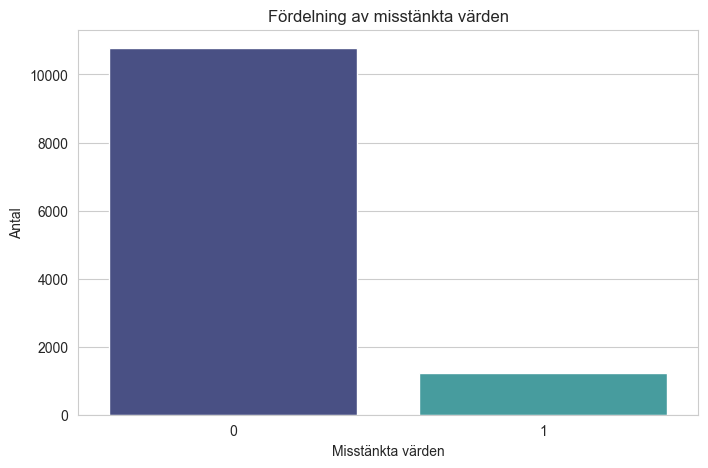

In [4]:
target_col = "is_suspicious"

print("Misstänkta värden (antal):")
print(df[target_col].value_counts())

print("\nMisstänkta värden (%):")
print(df[target_col].value_counts(normalize=True)* 100)

sns.set_style("whitegrid")

plt.figure(figsize=(8,5))

ax = sns.countplot(
    x=df[target_col],
    hue=df[target_col],
    palette="mako",
    legend=False
    )

plt.title("Fördelning av misstänkta värden")
plt.xlabel("Misstänkta värden")
plt.ylabel("Antal")
plt.show()

#### Slutsats:
Majoriteten av observationerna klassificeras som **ej misstänkta (89,8 %)** medan **10,2 % är misstänkta**. Datasetet är därför obalanserat, vilket är viktigt att ta hänsyn till vid modellutvärdering.

### Saknade värden

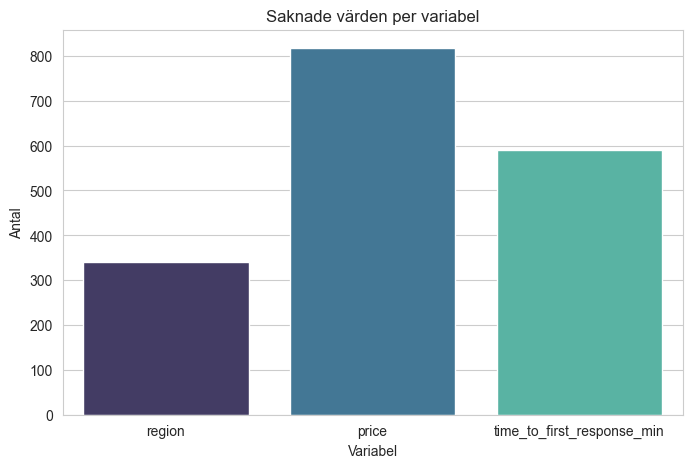

Saknade värden per kolumn:
region                        340
price                         818
time_to_first_response_min    590
dtype: int64


In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0]

sns.set_style("whitegrid")

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=missing.index,
    y=missing.values,
    hue=missing.index,
    palette="mako",
    legend=False
)

plt.title("Saknade värden per variabel")
plt.xlabel("Variabel")
plt.ylabel("Antal")
plt.show()

print("Saknade värden per kolumn:")
print(missing)

#### Slutsats: 
Analysen visar att datasetet innehåller en mindre andel saknade värden i variablerna region, price och time_to_first_response_min. Största andelen finns i price. 
Eftersom att andelen saknade värden är relativt liten i förhållande till storleken på hela datasetet, är det inte nödvändigt att ta bort dem.
De saknade numeriska värdena hanteras istället i preprocessing-steget genom att ersätta med **medianvärdet** för varje numerisk variabel, eftersom medianen påverkas mindre av extremvärden. 

De kategoriska värdena ersätts istället med **most_frequent** (det vanligaste värdet i kolumnen). Detta är lämpligt för kategoriska variabler eftersom det minimerar risken att skapa orealistiska eller nya kategorier.

## Train/test + preprocessing


### Uppdelning av features och target

Separerar features (X) och target-variabeln (y)  
Target är *is_suspicious* som anger om en händelse är misstänkt (1) eller inte (0)  
Kolumnen *id* tas bort från feature-setet eftersom den endast fungerar som en unik identifierare för varje rad och inte innehåller någon meningsfull information för prediktion. Att inkludera den skulle kunna leda till att modellen lär sig slumpmässiga mönster istället för faktiska samband i datan.

In [6]:
# Separerar features (X) och target (y)
X = df.drop(columns=[target_col, 'id'])
y = df[target_col]

### Train/Test-split

Delar upp datan i tränings- och testmängd (80/20) för att kunna utvärdera modellen på osedd data.

Använder stratifierad split (stratify=y) för att bevara klassfördelningen mellan misstänkta och icke-misstänkta händelser i båda mängderna.

Kontrollerar datamängdernas storlek samt klassfördelning för att verifiera att splitten genomförts korrekt.

In [7]:
# Delar upp i 80% träning och 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Kontroll av dimensioner och klassfördelning
print(f'Train: {X_train.shape, y_train.shape}')
print(f'Test:  {X_test.shape, y_test.shape}')

print(f'\nKlassfördelning Train \n{y_train.value_counts(normalize=True)}')
print(f'\nKlassfördelning Test \n{y_test.value_counts(normalize=True)}')

Train: ((9600, 16), (9600,))
Test:  ((2400, 16), (2400,))

Klassfördelning Train 
is_suspicious
0    0.898021
1    0.101979
Name: proportion, dtype: float64

Klassfördelning Test 
is_suspicious
0    0.897917
1    0.102083
Name: proportion, dtype: float64


### Identifiering av variabeltyper

För att kunna tillämpa rätt preprocessing delar vi upp våra features i två grupper: numeriska och kategoriska.

(Inkluderar både object och string för att säkerställa att alla textbaserade variabler fångas upp oavsett Pandas-version.)

**Verifiering**: Enligt vår EDA förväntar vi oss totalt 16 features (18 kolumner minus 'target' - 'id'). Vi kontrollerar att summan stämmer för att säkerställa att ingen data har fallit bort.

In [8]:
# Identifierar kolumner baserat på datatyp
numeric_features = X.select_dtypes(include=['number']).columns
categorical_features = X.select_dtypes(include=['object', 'string']).columns

# Kontroll av antal för att matcha EDA
print(f'Antal numeriska: {len(numeric_features)}')
print(f'Antal kategoriska: {len(categorical_features)}')
print(f'Total feautures: {len(numeric_features) + len(categorical_features)}')

print(f'\nNumeriska variabler: \n{numeric_features}')
print(f'\nKategoriska variabler: \n{categorical_features}')

Antal numeriska: 12
Antal kategoriska: 4
Total feautures: 16

Numeriska variabler: 
Index(['day', 'account_age_days', 'num_prev_listings', 'prev_reports_30d',
       'verification_level', 'price', 'num_images', 'message_length',
       'contains_off_platform', 'urgency_words', 'payment_attempt',
       'time_to_first_response_min'],
      dtype='str')

Kategoriska variabler: 
Index(['event_type', 'category', 'region', 'device'], dtype='str')


### Preprocessing Pipeline

**Numerisk hantering**: Vi använder median för imputation för att minimera påverkan från outliers, följt av StandardScaler för att normalisera skalorna.

**Kategorisk hantering**: Vi fyller saknade värden med det mest förekommande värdet (most_frequent) och omvandlar text till binära kolumner via OneHotEncoder.

**Driftsäkerhet**: Parametern handle_unknown='ignore' inkluderas för att hantera nya kategorier i framtida data utan att pipelinen avbryts.

**Exkludering av övrig data**: Med remainder='drop' säkerställer vi att endast de features vi valt ut (de i numeric_features och categorical_features) skickas vidare till modellen

In [9]:
# Pipeline för siffror
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline för text/kategorier
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Samlar alla transformationer i ett objekt
preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder= 'drop'
)

## Modellering och jämförelse

### Motivering till val av metric

Vi har två kostnader att jobba med: granskningstid och missade bedrägerier. 

* Hög Precision sparar granskningstid, men innebär fler missade bedrägerier
* Hög Recall minskar missade bedrägerier, men innebär högre granskningstid

F1-score är det harmoniska medelvärdet mellan Precision och Recall och ger oss möjligheten att ta hänsyn till båda dessa kostnader då F1-score blir låg om antingen Precision eller Recall är låg. 

### Skapa baseline och modeller

Vi väljer DummyClassifier med strategy = "stratified" som baseline. Vi väljer "stratified" istället för "most_frequent" för att "stratified" blir mer ärlig när vi använder F1-score för att jämföra våra modeller. 

DummyClassifier med "most_frequent" kommer alltid gissa is_not_suspicious vilket ger ett F1-score = 0 vilket inte blir så intressant att jämföra med. 

"stratified" gissar slumpmässigt, men vet hur stor andel av träningsdatan som är is_suspicious och ser till att gissa utifrån den fördelningen.

DummyClassifier med strategy="stratified" blir därför den mest realistiska "dumma" modellen att jämföra med. 

<br>

https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html

In [10]:
# Skapa baseline

baseline = DummyClassifier(strategy="stratified", random_state=42)

### Modeller att utvärdera

* LogisticRegression: snabb, linjär 
* DecisionTree: icke-linjär, bygger på flödesschema 
* RandomForest: ensemble-modell dvs en hel skog med DecisionTrees 

Vi valde dessa tre modeller för att få en bredd i vårt test. Med dessa modeller kan vi testa både linjärt vs icke-linjärt och enskild modell vs ensemble. 

#### Val av hyperparametrar inför test

Vi vill inte laborera med en massa olika hyperparametrar innan vi testar olika modeller för första gången. 

Att lägga för mycket tid och energi på hyperparametrarna i det här läget kan medföra att en modell får "mer kärlek" än en annan och att testresultatet därmed inte blir lika tillförlitigt.

Dock kan vi inte helt och hållet gå på default, utan måste anpassa modellen lite efter den träningsdata vi faktiskt har: 

* LogisticRegression
    * max_iter=1000, default är 100. =1000 ger modellen tillräckligt tid att räkna
    * class_weight="balanced", default är att klasserna är lika vanliga, men vi har obalanserad data. Med class_weight kan man styra straffvikten utifrån klassfördelningen i datan 
* DecisionTree
    * DecisionTree overfit:ar gärna. För att resultatet på ett rimligt sätt ska kunna jämföras mot andra modeller behövs hyperparametrar för att "stoppa upp" modellen i dess plugghästiga eftersträvan att svara rätt på varenda studiefråga
    * Dessa hyperparametrar stoppar upp modellen:
        * max_depth=5, default är None. 
        * min_samples_leaf=5, default är 2.
* RandomForest
    * Precis som med de två andra modellerna behöver vi anpassa modellen efter den obalanserade datan. Detta görs med class_weight:
        * class_weight="balanced_subsample", default är None. Med class_weight="balanced_subsample" beräknas straffvikten utifrån klassfördelningen i varje träd 

<br>


https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [11]:
# Skapar de tre modellerna som ska testas

logreg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

tree = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, class_weight="balanced", random_state=42)

rf = RandomForestClassifier(random_state=42, class_weight="balanced_subsample")

### Skapa pipelines

In [12]:
# Skapar pipelines för att koppla ihop vår preprocessing med varje modell 
# Detta gör vi för att förhindra dataläckage

pipe_baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", baseline)
])

pipe_logreg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", logreg)
])

pipe_tree = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", tree)
])

pipe_rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", rf)
])

### Utvärdera modellerna

#### Metod för utvärdering

Vi väljer att utvärdera de olika modellerna med Cross-Validation. 

I Cross-Validation delas träningsdatan upp i olika "tårtbitar" (vanligtvis 5). Sedan tränas och testas datan i olika rundor (antal rundor = antal tårtbitar). 

Detta gör så att all data blir testdata någon gång och resultatet därmed blir mer tillförlitligt. 

Med StratifiedKFold bestämmer vi hur datan ska delas upp. Vi väljer 5 "tårtbitar" och sätter shuffle till True (för en mer rättvis fördelning). Eftersom vi vet att datan är obalaserad är det _Stratified_ KFold vi använder oss av. 

Själva "magin" sker med funktionen cross_val_score. 

cross_val_score: 

- delar upp datan utifrån vår StratifiedKFold och kopierar modellen
- tränar kopian och gör sedan en predict
- gissningen jämförs mot target och F1-score beräknas 
- sedan gör samma sak på nästa tårtbit 

Vi lägger in cross_val_score i en for-loop för att kunna göra det på alla 4 modeller. 

Resultatet lägger vi i en lista som vi sedan gör om till en DataFrame för att ge en tydligare tabell.

<br>

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html 

https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation 

In [13]:
models = {
    "Baseline": pipe_baseline, 
    "LogisticRegression": pipe_logreg,
    "DecisionTree": pipe_tree,
    "RandomForest": pipe_rf
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = "f1"

results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=SCORING
    )
    results.append({
        "model": name,
        "mean_f1": scores.mean(),
        "std": scores.std()
    })

results_df = pd.DataFrame(results).sort_values("mean_f1", ascending=False)
results_df.reset_index(drop=True, inplace=True)
results_df.index += 1

print("Resultat av Cross-Validation:\n")
print(results_df)

best_model_name = results_df.iloc[0]["model"]
best_model_score = results_df.iloc[0]["mean_f1"]

print(f"\nDen bästa modellen är: {best_model_name} med F1-score {best_model_score:.3f}")

Resultat av Cross-Validation:

                model   mean_f1       std
1  LogisticRegression  0.297641  0.009516
2        DecisionTree  0.283092  0.007164
3            Baseline  0.092857  0.018649
4        RandomForest  0.008041  0.007468

Den bästa modellen är: LogisticRegression med F1-score 0.298


## Välj och optimera EN modell

### Hyperparameter-tuning 

De två bästa modellerna hade väldigt liknande F1-score. Vi valde den modell som hade det högsta värdet, **Logistic Regression**, även om skillnaden var liten. 

Eftersom detta var en första modelljämförelse valde vi den modell som presterade bäst enligt vårt primära (läs: enda) utvärderingsmått - högst F1-score.

Då vårt kravkort fokuserar på **kostnader och tradeoffs mellan granskningstid och missade bedrägerier**, är det viktigt att modellen både kan identifiera misstänkta fall och samtidigt undvika för många felaktiga flaggningar.

För att förbättra modellens prestanda genomförde vi därför en **hyperparameter-optimering med GridSearchCV**.

GridSearchCV testar olika kombinationer av parametrar och använder cross-validation för att hitta den kombination som ger bäst resultat enligt vald metric (F1-score).

Vi testade följande parametrar:

**C**

Regulariseringsstyrkan i Logistic Regression.
Ett lägre C-värde innebär starkare regularisering (en enklare modell), medan ett högre värde gör modellen mer flexibel.

**solver**

Algoritmen som används för att optimera modellen under träning.

**class_weight**

Används för att hantera obalanserad data genom att ge högre vikt till den mindre klassen, vilket är viktigt eftersom endast cirka 10 % av händelserna är misstänkta.

**imputer strategy**

Vi testade både median och mean för att se vilken metod som fungerar bäst för att hantera saknade numeriska värden.

Totalt testades flera kombinationer av dessa parametrar med **Stratified 5-fold cross-validation.**

Den kombination som gav högst F1-score valdes som slutmodell och används i de efterföljande analyserna, där vi analyserar olika threshold-värden för att hitta en rimlig balans mellan **granskningskostnad och risken att missa bedrägerier.**

In [14]:
# Modell med högst f1-score från utvärderingen

model = logreg

# Pipeline

final_pipeline = pipe_logreg

# Hyperparametrar att testa

param_grid = {
    "model__C": [0.0008, 0.001, 0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs", "liblinear"],
    "model__class_weight": [None, "balanced"],
    "preprocess__num__imputer__strategy": ["median", "mean"]
}

# GridSearch för att hitta bästa parameter

grid_search = GridSearchCV(
    estimator=final_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

# Träna modellerna

grid_search.fit(X_train, y_train)

# Bästa modellen

best_model = grid_search.best_estimator_

print("Bästa parametrar från GridSearch:\n")
for param_name, param_value in grid_search.best_params_.items():
    print(f"{param_name}: {param_value}")

print(f"\nBäst F1-score: {grid_search.best_score_:.3f}")

result = pd.DataFrame(grid_search.cv_results_)
print("\nSammanställning av GridSeach och korsvalidering (topp 5 kombinationer):")
result.sort_values("rank_test_score").head(5)

Bästa parametrar från GridSearch:

model__C: 0.0008
model__class_weight: balanced
model__solver: lbfgs
preprocess__num__imputer__strategy: median

Bäst F1-score: 0.302

Sammanställning av GridSeach och korsvalidering (topp 5 kombinationer):


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__class_weight,param_model__solver,param_preprocess__num__imputer__strategy,params,split0_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
4,0.032763,0.007535,0.008755,0.001008,0.0008,balanced,lbfgs,median,"{'model__C': 0.0008, 'model__class_weight': 'b...",0.301790,...,0.302135,0.010092,1,0.305980,0.310775,0.307841,0.310401,0.303894,0.307778,0.002615
5,0.026205,0.002309,0.008064,0.000748,0.0008,balanced,lbfgs,mean,"{'model__C': 0.0008, 'model__class_weight': 'b...",0.299233,...,0.301302,0.010067,2,0.305635,0.309360,0.308138,0.309749,0.305353,0.307647,0.001839
13,0.024269,0.000678,0.007520,0.000449,0.0010,balanced,lbfgs,mean,"{'model__C': 0.001, 'model__class_weight': 'ba...",0.299748,...,0.301241,0.009847,3,0.306868,0.310591,0.307202,0.312318,0.303940,0.308184,0.002953
12,0.030103,0.004868,0.007891,0.000793,0.0010,balanced,lbfgs,median,"{'model__C': 0.001, 'model__class_weight': 'ba...",0.299748,...,0.300790,0.008712,4,0.306431,0.310591,0.307202,0.313066,0.304851,0.308428,0.002982
22,0.032728,0.002834,0.007587,0.000359,0.0100,balanced,liblinear,median,"{'model__C': 0.01, 'model__class_weight': 'bal...",0.288351,...,0.298142,0.010852,5,0.310944,0.308199,0.299970,0.310189,0.302526,0.306366,0.004349


### Resultat av hyperparameter-optimering

GridSearchCV testade flera kombinationer av hyperparametrar för Logistic Regression.

Den bästa kombinationen valdes baserat på **mean_test_score (F1-score)** från cross-validation.

Vi jämförde även **mean_train_score** och **mean_test_score** för att kontrollera att modellen inte överanpassar träningsdatan.
Resultaten visar att skillnaden mellan tränings- och testscore är relativt liten, vilket tyder på att modellen generaliserar bra till ny data.

Den optimerade modellen används sedan i threshold-analysen där vi analyserar hur olika tröskelvärden påverkar:

* antal ärenden som behöver granskas
* antal misstänkta fall som missas

Detta gör det möjligt att tydligt visa **tradeoffen mellan kostnad och risk**, vilket är centralt för den stakeholder vi pitchar till.

## Threshold / prioritering (kopplat till kravkortet)


### Val av prioriteringsstrategi

Vi använder **Alternativ A** - Threshold-beslut.  
En händelse flaggas som misstänkt om modellens sannolikhet överstiger vald threshold.  
Genom att justera threshold kan vi styra hur många händelser som flaggas:

**Lägre threshold:** fler flaggade händelser → färre misstänkta missas, men mer granskning krävs.

**Högre threshold:** färre flaggade händelser → mindre granskning, men fler misstänkta missas.


### Modellens standardprediktion (utgångspunkt)  
Som utgångspunkt använder vi modellens default threshold 0.5, vilket innebär att en händelse klassificeras som misstänkt om sannolikheten ≥ 0.5.  
Confusion matrix nedan visar modellens prestation på testdatan med denna threshold:

- **True Positives (TP)** – misstänkta händelser som korrekt flaggas
- **False Positives (FP)** – oskyldiga händelser som flaggas i onödan
- **False Negatives (FN)** – misstänkta händelser som modellen missar
- **True Negatives (TN)** – korrekta icke-misstänkta prediktioner

Matris fungerar som en **utgångspunkt**.  
Därefter undersöker vi hur resultaten förändras när vi justerar threshold-värdet och därmed prioriteringsstrategin.

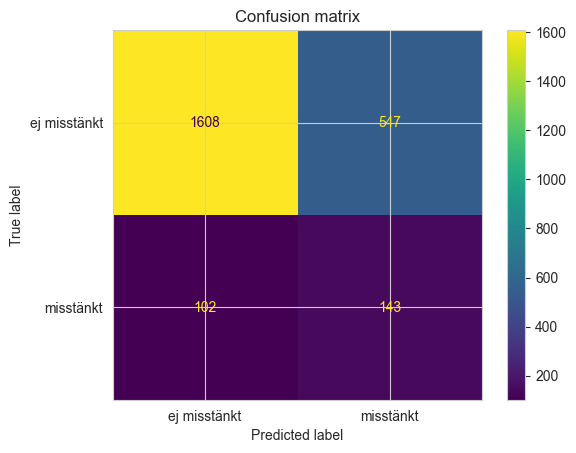

In [15]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

target_names = ["ej misstänkt", "misstänkt"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

disp.plot()
plt.title("Confusion matrix")
plt.show()

### Modellens prestanda med standard-threshold (0.5)

Av de **2155 ej misstänkta** händelserna klassificeras **1608 korrekt**, medan **547 felaktigt** flaggas som misstänkta.  
Av de **245 misstänkta** händelserna identifieras **143 korrekt**, medan **102 missas** av modellen.

Detta innebär att modellen har hög accuracy, men låg recall för misstänkta händelser, vilket betyder att många misstänkta fall inte fångas vid detta threshold.

Nedan beräknar vi några vanliga prestationsmått för modellen:  
- Accuracy – andel korrekta prediktioner totalt  
- Precision – hur stor andel av de flaggade fallen som faktiskt är misstänkta  
- Recall – hur stor andel av de verkligt misstänkta fallen som modellen hittar  
- F1-score – ett mått som väger ihop precision och recall

Vi skriver även ut ett classification report för att få en mer detaljerad bild av modellens resultat.

In [16]:
test_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred)
    ]
})

print(test_results)
print()

print("Classification report: \n", classification_report(y_test, y_pred))

      Metric     Score
0   Accuracy  0.729583
1  Precision  0.207246
2     Recall  0.583673
3   F1-score  0.305882

Classification report: 
               precision    recall  f1-score   support

           0       0.94      0.75      0.83      2155
           1       0.21      0.58      0.31       245

    accuracy                           0.73      2400
   macro avg       0.57      0.66      0.57      2400
weighted avg       0.87      0.73      0.78      2400



### Analys av olika threshold-värden

Istället för att enbart använda modellens standardthreshold (0.5) analyserar vi hur modellens beteende förändras vid olika thresholds.

Vi använder modellens predikterade sannolikheter (predict_proba) och testar fem olika threshold-värden: **0.4, 0.45, 0.5, 0.55 och 0.6.**

För varje threshold beräknar vi:  
- flagged_cases – antal händelser som flaggas för granskning  
- false_positives – oskyldiga händelser som flaggas i onödan  
- false_negatives – misstänkta händelser som modellen missar  
- precision – andel av de flaggade fallen som faktiskt är misstänkta  
- recall – andel av de verkligt misstänkta fallen som modellen identifierar

Syftet är att analysera hur valet av threshold påverkar balansen mellan granskningstid och risken att missa misstänkta händelser

In [17]:
# Prediktera sannolikheter
y_proba = best_model.predict_proba(X_test)[:,1]

thresholds = [0.4, 0.45, 0.5, 0.55, 0.6]

results = []

for t in thresholds:

    y_pred = (y_proba >= t).astype(int)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    results.append({
        "threshold": t,
        "flagged_cases": y_pred.sum(),
        "false_positives": fp,
        "false_negatives": fn,
        "precision": precision,
        "recall": recall
    })

results_df = pd.DataFrame(results)

results_df

,threshold,flagged_cases,false_positives,false_negatives,precision,recall
0,0.40,1569,1358,34,0.134481,0.861224
1,0.45,1158,962,49,0.169257,0.800000
2,0.50,690,547,102,0.207246,0.583673
3,0.55,491,365,119,0.256619,0.514286
4,0.60,320,232,157,0.275000,0.359184


### Visualisering av tradeoff
För att se den fullständiga bilden av hur kostnaderna rör sig mellan dessa punkter har vi också tagit fram en tradeoff-graf. 
Den hjälper oss att identifiera den punkt där vi får bäst balans mellan operativt arbete och risk.

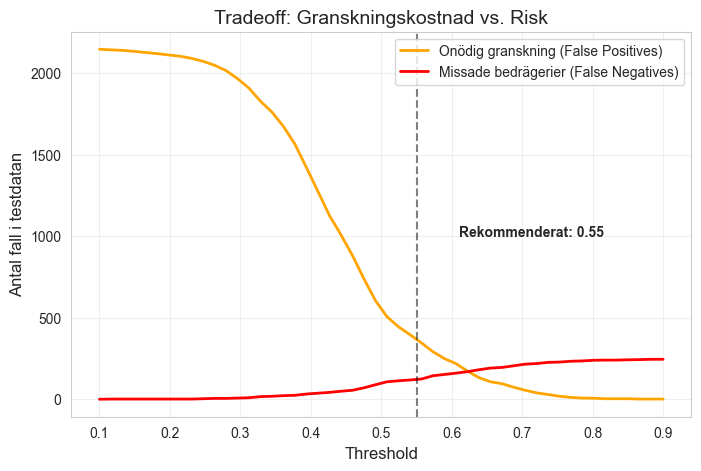

In [18]:
# Skapa intervall av thresholds för graf
threshold_range = np.linspace(0.1, 0.9, 50)
fps = []
fns = []

for t in threshold_range:
    y_pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    fps.append(fp)
    fns.append(fn)

plt.figure(figsize=(8, 5))
plt.plot(threshold_range, fps, label='Onödig granskning (False Positives)', color='orange', lw=2)
plt.plot(threshold_range, fns, label='Missade bedrägerier (False Negatives)', color='red', lw=2)

# Marker vald threshold (0.6)
plt.axvline(x=0.55, color='black', linestyle='--', alpha=0.5)
plt.text(0.61, 1000, 'Rekommenderat: 0.55', fontweight='bold')

plt.title('Tradeoff: Granskningskostnad vs. Risk', fontsize=14)
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Antal fall i testdatan', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Tolkning

Resultatet visar tydligt hur valet av threshold påverkar modellens beteende.

En **lägre threshold** (0.4) gör att många **fler händelser flaggas**, 1569 stycken. Detta gör att modellen fångar de flesta misstänkta fall (hög recall), men leder också till många false positives, vilket innebär **mer arbete för granskningsteamet.**

En **högre threshold** (0.6) gör tvärtom att **färre händelser flaggas**, 320 stycken. Precisionen blir högre, men modellen **missar många misstänkta fall** (låg recall).

Threshold 0.55 ligger mellan dessa två. Den flaggar 491 händelser, vilket minskar granskningsarbetet jämfört med 0.50, samtidigt som modellen fortfarande identifierar en del misstänkta fall.

**Vi rekommenderar Threshold 0.55.** Det är den mest kostnadseffektiva nivån där vi maximerar analytikernas tid utan att släppa igenom för stora volymer risk

## Deploy-test: ny data (tisdag kursvecka 6)

När ni får new_data.csv ska ni:
använda er låsta pipeline
skapa prediktioner och en prioriteringslista

### Spara pipeline
Den slutliga modellen sparades som en komplett pipeline med hjälp av joblib.  

Pipelinen innehåller både preprocessing-steg (imputation, skalning och one-hot-encoding) samt den tränade modellen.  

Genom att spara hela pipelinen säkerställs att exakt samma preprocessing används vid prediktion på ny data.

In [19]:
# Filnamn för pipelinen
model_path = Path('pipeline.joblib')

# Spara den bästa modellen (hela pipelinen)
joblib.dump(best_model, model_path)

# Skriver ut path för att se att pipelinen sparats
print("Pipeline sparad till:", model_path.resolve())

# Testa att modellen går att ladda och ger samma resultat
pipeline_loaded = joblib.load(model_path)

# Prediktera igen
proba_loaded = pipeline_loaded.predict_proba(X_test)[:, 1]

# jämför med tidigare prediktioner
max_diff = np.max(np.abs(proba_loaded - y_proba))

# Skriver ut max skillnad - Ska vara 0.0
print("Max skillnad mellan original och laddad modell:", max_diff)


# y_proba = best_model.predict_proba(X_test)[:,1]

Pipeline sparad till: C:\Users\josef\Desktop\Machine Learning\grupparbete ny\pipeline.joblib
Max skillnad mellan original och laddad modell: 0.0


### Ladda ny data

In [20]:
df_new = pd.read_csv("new_data.csv")


### Skapa prediktioner

In [21]:
new_proba = pipeline_loaded.predict_proba(df_new)[:, 1]

### Skapa topplista

In [22]:
pred = (new_proba >= 0.55).astype(int)

new_results = df_new.copy()
new_results["probability"] = new_proba
new_results["prediction"] = pred
new_results = new_results.sort_values("probability", ascending=False)

print("Topp 20-lista (högst sannolikhet):")
new_results.head(20)

Topp 20-lista (högst sannolikhet):


,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,probability,prediction
1092,1092,2,ad_post,furniture,metro,android,27.9,5,2,0,NaN,3,64,1,0,0,8.8,0.896381,1
1398,1398,5,message_send,other,rural,android,31.4,3,1,0,235.12,1,189,1,1,0,13.9,0.881454,1
1547,1547,3,ad_post,other,metro,android,46.1,1,1,0,128.28,7,141,1,0,1,71.2,0.857137,1
1130,1130,1,ad_post,phones,urban,android,23.5,3,2,1,169.80,3,229,1,0,0,5.2,0.850827,1
1538,1538,2,ad_post,phones,urban,android,47.8,3,2,1,227.32,0,158,1,0,0,22.2,0.839661,1
1831,1831,3,ad_post,furniture,NaN,ios,15.4,3,1,0,90.61,5,125,1,0,0,NaN,0.828646,1
3,3,5,ad_post,phones,rural,ios,81.3,5,0,1,1152.26,8,72,1,1,1,2.8,0.826882,1
124,124,4,message_send,other,rural,android,16.0,4,1,0,99.13,6,156,1,0,0,25.4,0.824065,1
486,486,5,ad_post,fashion,rural,android,11.7,2,1,0,292.44,4,213,1,0,0,NaN,0.822684,1
792,792,5,ad_post,fashion,metro,android,39.3,3,1,0,112.67,1,9,0,1,1,14.5,0.820739,1


### Jämförelse av prediktioner på historisk resp. ny data

In [23]:
# Ny data

num_flagged = new_results["prediction"].sum()
 
share_flagged = num_flagged / len(new_results)

# Historisk data

value = results_df.loc[3, "flagged_cases"]

value_percent = value / len(y_test) * 100

print(f"Antal flaggade misstänkta (ny data): {num_flagged}")
print(f"Andel flaggade procent (ny data): {share_flagged:.2%}")

print(f"\nAntal flaggade misstänkta (historisk data): {value}")
print(f"Andel flaggade procent (historisk data): {value_percent:.2f}%")

Antal flaggade misstänkta (ny data): 478
Andel flaggade procent (ny data): 23.90%

Antal flaggade misstänkta (historisk data): 491
Andel flaggade procent (historisk data): 20.46%


Det är ett bra tecken att antalet/andelen flaggade i både historisk och ny data är rätt så lika.

- Pipen verkar vara tekniskt stabil
- Den nya datan kunde processeras utan fel
- Modellen kunde köras end-to-end på ny data
- Outputen ser rimlig ut på en övergripande nivå

## Varför fick RandomForest ett sånt dåligt resultat...?

Trots goda avsikter fick inte RandomForest rättvisa start-hyperparametrar i modelljämförelsen. 

Precis som DecisionTree-modellen bör RandomForest ha fått lite begränsningar med max_depth och min_samples_leaf för att få chansen att prestera bättre på osedd data. 

Vi upptäckte det, men valde att gå vidare utan att ändra något, och har kvar detta fel som en ödmjuk påminnelse att man kan faktiskt inte vara bäst hela tiden.

Bara *nästan* hela tiden. 

Dock kunde vi inte släppa det helt och hållet och testade att göra en CrossValidation med lite fler rättvisa parametrar i RandomForest-modellen (max_depth=5 och min_samples_lead=5).

Och tro det eller ej, men då fick RandomForest bäst F1-score...! Med 0,307 jämfört med 0,298. 

Aja, tur man lär sig nåt nytt hela tiden...

## Risker, begränsningar och nästa steg



### Risker och begränsningar

- Modellen är tränad på historisk data. Bedragare kan och kommer ändra sina beteenden (exempelvis sluta använda vissa "urgency words") vilket gör att modellens träffsäkerhet kommer sjunka över tid
- Datakvalitet: dålig data ger dåligt resultat. Exempelvis används imputing för att hantera saknade värden som innebär att modellen gissar i de fall där information saknas, vilket blir en inbyggd osäkerhet 
- Under perioder med ovanligt hög aktivitet på plattformen kan även en låg andel False Negatives (missade bedrägerier) innebära ett stort antal bluffannonser pga den totala volymökningen 
    - Och samma för False Positives
- Modellen ignorerar ny information för att inte krascha, tekniskt nödvändigt, men något att hantera framledes

### Nästa steg

- Jämföra modellens prestation på den nya datan med facit
- A/B-testning: jämföra ML med threshold 0.55 mot nuvarande process 
- Feedback-loop från Trust & Safety-teamet - faktiska beslut (True/False) skickas tillbaka till modellen
- Övervakning av "model drift": sätta upp larm som varnar om modellens prestation börjar sjunka
- Implementera en logg som flaggar när systemet ignorerar större mängd ny data 
- Implementera förklarbarhetsstöd (XAI, Explainable AI): ge Trust & Safety-teamet möjlighet att kommunicera *varför* en annons blev flaggad som bluff/spam med hjälp av SHAP (SHapley Additive exPlanations)
- Utöka modellen med textanalys (NLP)
